### Setting up the Environment and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
import os

warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.2f}'.format)


plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


RAW_PATH      = '../data/weekly_base_bundles_info_202501_202510.csv'
INTERIM_PATH  = '../data/interim/telecom_bundles_cleaned.csv'
PROCESSED_PATH= '../data/processed/telecom_bundles_final.csv'

print("The environment is ready.")

The environment is ready.


In [62]:
df = pd.read_csv(RAW_PATH)
df_backup = df.copy()  # Backup copy in memory

print(f" Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

 Loaded: 42,377 rows × 15 columns


In [63]:

df.dropna(subset=['bundle_id', 'bundle_name', 'bundle_type'], inplace=True)


df = df[df['service_class_category'] != 'STAFF']


df = df[df['bundle_type'] != 'VAS']

df = df[~df['bundle_name'].str.contains("DIY", case=False, na=False)]

df.drop('total_duration', axis=1, inplace=True, errors='ignore')


n_duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {n_duplicates}")
df.drop_duplicates(inplace=True)


print(f"Final Size: {df.shape}")
print(f"Removed {42377 - len(df):,} Rows in total")

Duplicate Rows: 0
Final Size: (38102, 14)
Removed 4,275 Rows in total


In [64]:
df.info()

<class 'pandas.DataFrame'>
Index: 38102 entries, 0 to 42376
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             38102 non-null  int64  
 1   year_number             38102 non-null  int64  
 2   bundle_id               38102 non-null  str    
 3   bundle_name             38102 non-null  str    
 4   bundle_type             38102 non-null  str    
 5   validity                38046 non-null  str    
 6   price                   38068 non-null  str    
 7   usage_type              38102 non-null  str    
 8   configured_volume       34588 non-null  str    
 9   service_class_category  37630 non-null  str    
 10  total_rev               38102 non-null  float64
 11  total_subscriptions     38102 non-null  int64  
 12  total_sessions          38102 non-null  int64  
 13  unique_users            38102 non-null  int64  
dtypes: float64(1), int64(5), str(8)
memory usage: 4.4 MB


In [65]:

def parse_validity(value):
    """
    Converts non-standard validity text values into (number, unit)
    with specific business logic for unit conversion.

    """
    if pd.isna(value):
        return np.nan, np.nan

    v = str(value).strip().lower()
    v = re.sub(r'\s+', ' ', v)  # Standardize spacing

    number_match = re.search(r'(\d+)', v)
    if not number_match:
        return np.nan, np.nan

    number = int(number_match.group(1))

    
    if 'hour' in v:
        unit = 'Hourly'
    elif 'day' in v:
        unit = 'Daily'
    elif 'month' in v:
        unit = 'Monthly'
    else:
        return number, np.nan

    
    # Convert 24 Hours to 1 Day
    if unit == 'Hourly' and number == 24:
        number = 1
        unit = 'Daily'
    
    # Convert 30 or 31 Days to 1 Month
    elif unit == 'Daily' and (number == 30 or number == 31 ):
        number = 1
        unit = 'Monthly'

    return number, unit



df[['validity_value', 'validity_unit']] = df['validity'].apply(
    lambda x: pd.Series(parse_validity(x))
)


print("Distribution of validity_unit:")
print(df['validity_unit'].value_counts(dropna=False))

# # Filling missing values
# # Best practice: use median for values and mode for categorical units
df['validity_value'].fillna(df['validity_value'].median(), inplace=True)
df['validity_unit'].fillna(df['validity_unit'].mode()[0], inplace=True)


unit_order = {'Hourly': 0, 'Daily': 1, 'Monthly': 2}
df['validity_unit_encoded'] = df['validity_unit'].map(unit_order)

print("\n Validity preprocessing complete")
display(df[['validity', 'validity_value', 'validity_unit', 'validity_unit_encoded']].head(5))

Distribution of validity_unit:
validity_unit
Daily      26853
Monthly    11182
NaN           56
Hourly        11
Name: count, dtype: int64

 Validity preprocessing complete


,validity,validity_value,validity_unit,validity_unit_encoded
0,30 Day(s),1.00,Monthly,2.00
1,30 Day(s),1.00,Monthly,2.00
2,30 Day(s),1.00,Monthly,2.00
3,1 Day(s),1.00,Daily,1.00
4,30 Day(s),1.00,Monthly,2.00


In [66]:

df.dropna(subset=['validity_value', 'validity_unit','validity_unit_encoded'], inplace=True)


df.reset_index(drop=True, inplace=True)


print(f"Missing records removed successfully.")
print(f"Remaining record count: {len(df):,}")
print(f"Missing values in validity columns now:\n{df[['validity_value', 'validity_unit','validity_unit_encoded']].isnull().sum()}")

Missing records removed successfully.
Remaining record count: 38,046
Missing values in validity columns now:
validity_value           0
validity_unit            0
validity_unit_encoded    0
dtype: int64


In [67]:

def clean_price_final(value):
    """
    Cleans price column from currency symbols, spaces, and handles formatting.
    Targeted for VAE where preserving high-value signal is critical.
    """
    if pd.isna(value):
        return np.nan
    
    
    cleaned = re.sub(r'[^\d.,]', '', str(value))
    

    if ',' in cleaned and '.' in cleaned:
        cleaned = cleaned.replace(',', '')
    
    elif ',' in cleaned:
        cleaned = cleaned.replace(',', '.')
        
    try:
        return float(cleaned)
    except ValueError:
        return np.nan


print("Cleaning price column...")
df['price_clean'] = df['price'].apply(clean_price_final)


# We use Median because it's robust against the extreme skewness in your data
median_price = df['price_clean'].median()
df['price_clean'] = df['price_clean'].fillna(median_price)


print(f" Price cleaning complete.")
print(f"Stats — Min: {df['price_clean'].min():,.0f} | Max: {df['price_clean'].max():,.0f} | Median: {median_price:,.0f}")


display(df[['price', 'price_clean']].head(10))

df[['price_clean']].info()

Cleaning price column...
 Price cleaning complete.
Stats — Min: 10 | Max: 396,900 | Median: 700


,price,price_clean
0,4000,4000.00
1,690,690.00
2,200,200.00
3,215,215.00
4,50050,50050.00
5,1500,1500.00
6,590,590.00
7,185,185.00
8,122,122.00
9,50,50.00


<class 'pandas.DataFrame'>
RangeIndex: 38046 entries, 0 to 38045
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price_clean  38046 non-null  float64
dtypes: float64(1)
memory usage: 297.4 KB


In [68]:


TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',
    'FLEXI_BUNDLE': 'MIXED',   
}



patterns = {
    'DATA': [
        r'(\d[\d,.]*)\s*gb',
        r'(\d[\d,.]*)\s*go',
        r'(\d[\d,.]*)\s*mb',
        r'(\d[\d,.]*)\s*mo',
    ],
    'VOICE': [
        r'(\d[\d,.]*)\s*mn',
        r'(\d[\d,.]*)\s*min',
        r'(\d[\d,.]*)\s*mins',
        r'(\d[\d,.]*)\s*appel',
        r'(\d[\d,.]*)\s*voc',
    ],
    'SMS': [
        r'(\d[\d,.]*)\s*sms',
        r'(\d[\d,.]*)\s*msg',
    ],
}


MIXED_ORDER = ['DATA', 'VOICE', 'SMS']

unlimited_patterns = [
    r'illimit', r'unlimit', r'illimité', r'unlimité',
    r'illimitée', r'unlimitée', r'infini',
]

UNIT_MAP = {
    'DATA': {
        r'(\d[\d,.]*)\s*gb': 'GB',
        r'(\d[\d,.]*)\s*go': 'GB',
        r'(\d[\d,.]*)\s*mb': 'MB',
        r'(\d[\d,.]*)\s*mo': 'MB',
    },
    'VOICE': {
        r'(\d[\d,.]*)\s*mn':    'min',
        r'(\d[\d,.]*)\s*min':   'min',
        r'(\d[\d,.]*)\s*mins':  'min',
        r'(\d[\d,.]*)\s*appel': 'appel',
        r'(\d[\d,.]*)\s*voc':   'voc',
    },
    'SMS': {
        r'(\d[\d,.]*)\s*sms': 'SMS',
        r'(\d[\d,.]*)\s*msg': 'msg',
    },
}




_VOICE_UNITS_RE = re.compile(r'(\d[\d,.]*)\s*(mins?|mn|sec|s)', re.IGNORECASE)

def _parse_complex_voice(text):
    """
    Finds all occurrences of minutes and seconds, sums them up, 
    and converts seconds to decimal minutes.
    """
    hits = _VOICE_UNITS_RE.findall(text)
    if not hits:
        return None
    
    total_minutes = 0.0
    for val, unit in hits:
        
        num = float(val.replace(',', '.'))
        if unit.lower() in ['sec', 's']:
            total_minutes += num / 60  
        else:
            total_minutes += num
            

    if len(hits) >= 2:
        
        if total_minutes == int(total_minutes):
            return f"{int(total_minutes)}min"
        else:
            return f"{round(total_minutes, 2)}min"
    
    return None



def _search_type(name_lower, btype):
    """Search for the first matching pattern for the bundle type and return value with unit."""
    for pat in patterns.get(btype, []):
        m = re.search(pat, name_lower, re.IGNORECASE)
        if m:
            raw = m.group(1).replace(',', '.')
            unit = UNIT_MAP.get(btype, {}).get(pat, '')
            return f"{raw}{unit}"
    return None



def extract_volume_from_name(bundle_name, bundle_type):
    name_lower = str(bundle_name).lower()
    raw_type   = str(bundle_type).upper().strip()
    btype      = TYPE_MAP.get(raw_type, raw_type)  

    
    for pat in unlimited_patterns:
        if re.search(pat, name_lower, re.IGNORECASE):
            return 'Unlimited'

   
    if btype in ('VOICE', 'MIXED'):
        complex_result = _parse_complex_voice(bundle_name)
        if complex_result:
            return complex_result

    
    if btype == 'MIXED':
        for t in MIXED_ORDER:
            result = _search_type(name_lower, t)
            if result:
                return result
        return None

    
    return _search_type(name_lower, btype)



missing_mask = df['configured_volume'].isna()
print(f"Missing values before processing : {missing_mask.sum()}")


if 'volume_fill_source' not in df.columns:
    df['volume_fill_source'] = 'original'

for idx in df.index[missing_mask]:
    bundle_name = str(df.at[idx, 'bundle_name'])
    bundle_type = str(df.at[idx, 'bundle_type'])
    extracted   = extract_volume_from_name(bundle_name, bundle_type)
    
    if extracted is not None:
        df.at[idx, 'configured_volume'] = extracted
        df.at[idx, 'volume_fill_source'] = 'extracted_from_name'
    else:
        df.at[idx, 'volume_fill_source'] = 'not_found'

still_missing = df['configured_volume'].isna().sum()
filled        = missing_mask.sum() - still_missing

print(f"Successfully filled              : {filled}")
print(f"Still missing (not_found)        : {still_missing}")



print("\nSample of rows that were filled:")
display(df[df['volume_fill_source'] == 'extracted_from_name'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(20))

print("\nSample of rows that were NOT filled:")
display(df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].drop_duplicates('bundle_name').head(20))

Missing values before processing : 3458
Successfully filled              : 2029
Still missing (not_found)        : 1429

Sample of rows that were filled:


,bundle_name,bundle_type,configured_volume
32,Forfait EBU 1050 SMS 30 Jours@1100F,BUNDLE_SMS,1050SMS
40,Forfait tous reseaux 67 mins 7 jour@3000F,BUNDLE_VOICE,67min
62,Basic -330 mn - 4950F,BUNDLE_VOICE,330min
84,Forfait tous reseaux 456 mins 30 jour@20500F,BUNDLE_VOICE,456min
101,Forfait MagicVoice 30 jours 318 mins @3500F,BUNDLE_VOICE,318min
115,Forfait appels 5 mins 1 jour@15F,BUNDLE_VOICE,5min
132,Forfait tous reseaux 10 mins 1 jour@450F + BONUS,BUNDLE_VOICE,10min
152,Forfait appels 5 mins 1 jour@25F,BUNDLE_VOICE,5min
155,Illimite 2H par jour pendant 30 Jours@5500F,BUNDLE_DATA,Unlimited
163,Forfait tous reseaux 2 mins 1 jour@100F + BONUS,BUNDLE_VOICE,2min



Sample of rows that were NOT filled:


,bundle_name,bundle_type,configured_volume
8,SMS Bundle 3 Days@122F,BUNDLE_SMS,NaN
20,SMS Bundle 1 Day @26F,BUNDLE_SMS,NaN
61,Flexi Bundle 2 Days @220F,FLEXI_BUNDLE,NaN
86,Flexi Bundle 2 Days @450F,FLEXI_BUNDLE,NaN
89,SMS Bundle 1 Day @41F,BUNDLE_SMS,NaN
107,SMS Bundle 10 Days@507F,BUNDLE_SMS,NaN
162,Flexi Bundle 7 Days @840F,FLEXI_BUNDLE,NaN
179,SMS Bundle 1 day@15F,BUNDLE_SMS,NaN
194,SMS Bundle 5 Days@335F,BUNDLE_SMS,NaN
206,Flexi Bundle 7 Days @420F,FLEXI_BUNDLE,NaN


In [69]:


not_found_df = df[df['volume_fill_source'] == 'not_found'][
    ['bundle_name', 'bundle_type', 'configured_volume']
].copy()

print(f"Total unfilled rows: {len(not_found_df)}")
print("\n" + "="*60)


print("\nbundle_type distribution for unfilled values:")
print(not_found_df['bundle_type'].value_counts())

print("\n" + "="*60)


for btype in not_found_df['bundle_type'].unique():
    sample = not_found_df[not_found_df['bundle_type'] == btype]['bundle_name'].unique()[:15]
    print(f"\n[{btype}] — Sample bundle names:")
    for name in sample:
        print(f"    {name}")

print("\n" + "="*60)


print("\nTop 20 most frequent bundle_names in unfilled rows:")
print(not_found_df['bundle_name'].value_counts().head(20))

Total unfilled rows: 1429


bundle_type distribution for unfilled values:
bundle_type
BUNDLE_SMS      881
FLEXI_BUNDLE    372
BUNDLE_VOICE    171
BUNDLE_DATA       5
Name: count, dtype: int64


[BUNDLE_SMS] — Sample bundle names:
    SMS Bundle 3 Days@122F
    SMS Bundle 1 Day @26F 
    SMS Bundle 1 Day @41F 
    SMS Bundle 10 Days@507F
    SMS Bundle 1 day@15F
    SMS Bundle 5 Days@335F
    SMS Bundle 2 Days @66F 
    SMS Bundle 1 day@50F
    SMS Bundle 3 Days@100F

[FLEXI_BUNDLE] — Sample bundle names:
    Flexi Bundle 2 Days @220F 
    Flexi Bundle 2 Days @450F 
    Flexi Bundle 7 Days @840F 
    Flexi Bundle 7 Days @420F 
    Flexi Bundle 2 Days @120F 
    Flexi Bundle 2 Days @150F 
    Flexi Bundle 2 Days @200F 
    Flexi Bundle 2 Days @107F 
    Flexi Bundle 7 Days @1050F 
    Flexi Bundle 2 Days @600F 
    Flexi Bundle 7 Days @1400F 
    Flexi Bundle 7 Days @750F 
    Flexi Bundle 7 Days @3150F 

[BUNDLE_VOICE] — Sample bundle names:
    PRO GFU 10-23750F
    PRO GFU 20-46000F
 

In [53]:
df[['configured_volume']].info()

<class 'pandas.DataFrame'>
Index: 38102 entries, 0 to 42376
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   configured_volume  36617 non-null  str  
dtypes: str(1)
memory usage: 1.6 MB


In [70]:

_NAME_DATA_PATTERNS = [
    (r'(\d[\d,.]*)\s*gb', 'GB'),
    (r'(\d[\d,.]*)\s*go', 'GB'),
    (r'(\d[\d,.]*)\s*mb', 'MB'),
    (r'(\d[\d,.]*)\s*mo', 'MB'),
]

TYPE_MAP = {
    'BUNDLE_VOICE': 'VOICE',
    'BUNDLE_SMS':   'SMS',
    'BUNDLE_DATA':  'DATA',
    'FLEXI_BUNDLE': 'MIXED',
}


_VOICE_COMPOUND_RE = re.compile(
    r'(\d[\d,.]*)\s*(?:mins?|mn)[^,]*?(\d[\d,.]*)\s*(?:sec|s)\b',
    re.IGNORECASE
)


def _unit_from_name(bundle_name):
    """Infers the unit from the bundle name if the volume figure is unitless."""
    name_lower = str(bundle_name).lower()
    for pat, unit in _NAME_DATA_PATTERNS:
        if re.search(pat, name_lower, re.IGNORECASE):
            return unit
    return 'MB'  

def _parse_raw(volume_str, bundle_type, bundle_name):
    """Parses raw text into a (value, unit) tuple."""
    if pd.isna(volume_str):
        return np.nan, np.nan

    v = str(volume_str).strip().lower()

  
    if v.lower() in ('unlimited', 'illimité', 'illimitée', 'unlimitée', 'infini'):
        return -1.0, 'Unlimited'

    btype = TYPE_MAP.get(str(bundle_type).upper().strip(), str(bundle_type).upper().strip())

    
    compound = _VOICE_COMPOUND_RE.search(v)
    if compound:
        mins = float(compound.group(1).replace(',', '.'))
        secs = float(compound.group(2).replace(',', '.'))
        return round(mins + secs / 60, 4), 'min'

    
    m = re.search(r'(\d[\d,.]*)\s*([a-zA-Z]*)', v.replace('\xa0', ' '))
    if not m:
        return np.nan, np.nan

    num_str = m.group(1).replace(' ', '').replace(',', '.')
    unit_str = m.group(2).strip().lower()

    try:
        num = float(num_str)
    except ValueError:
        return np.nan, np.nan

    
    if unit_str in ('gb', 'go', 'g'):
        return num, 'GB'
    elif unit_str in ('mb', 'mo'):
        return num, 'MB'
    elif unit_str in ('min', 'mins', 'mn'):
        return num, 'min'
    elif unit_str == 'sms':
        return num, 'SMS'
    elif unit_str == '':
        if btype == 'VOICE': return num, 'min'
        elif btype == 'SMS': return num, 'SMS'
        else: return num, _unit_from_name(bundle_name)
    else:
        return num, unit_str.upper()

def standardize_volume(row):
    """Converts all units to a standard baseline (MB, min, SMS)."""
    raw_val, raw_unit = _parse_raw(
        row['configured_volume'],
        row['bundle_type'],
        row['bundle_name']
    )

    if pd.isna(raw_val):
        return np.nan, np.nan

    if raw_unit == 'Unlimited':
        return -1.0, 'Unlimited'

    if raw_unit in ['GB', 'G']:
        return round(raw_val * 1024, 4), 'MB'
    elif raw_unit == 'MB':
        return raw_val, 'MB'
    elif raw_unit == 'min':
        return raw_val, 'min'
    elif raw_unit == 'SMS':
        return int(raw_val), 'SMS'
    else:
        return raw_val, raw_unit




has_value = df['configured_volume'].notna()


results = df[has_value].apply(standardize_volume, axis=1, result_type='expand')
results.columns = ['volume_value', 'volume_unit']


df = df.drop(columns=['volume_value', 'volume_unit'], errors='ignore')


df = df.join(results)


for unit_type in ['MB', 'min', 'SMS']:
    mask = (df['volume_unit'] == unit_type) & (df['volume_value'].isna())
    median_val = df.loc[df['volume_unit'] == unit_type, 'volume_value'].median()
    if pd.notna(median_val):
        df.loc[mask, 'volume_value'] = median_val


print("Volume Processing Complete")
print("\nUnits Distribution:")
print(df['volume_unit'].value_counts(dropna=False))

print(f"\nRemaining missing values: {df['volume_value'].isna().sum()}")


display(df[has_value][['bundle_name', 'configured_volume', 'volume_value', 'volume_unit']].head(10))

Volume Processing Complete

Units Distribution:
volume_unit
MB           17584
min          17155
NaN           1438
Unlimited     1038
SMS            831
Name: count, dtype: int64

Remaining missing values: 1438


,bundle_name,configured_volume,volume_value,volume_unit
0,Forfait 1.6Go 30 jours@4000F,1.61,1648.64,MB
1,Forfait appels RCA 2 mins 30 jours@690F,2MIN,2.00,min
2,Forfait appels Nigeria 2 mins 30 jours@200F,2MIN,2.00,min
3,Forfait 1 jour 170MB@215F,170,170.00,MB
4,NDAKO BOX ILLIMITE@50050F,Unlimited,-1.00,Unlimited
5,Int Bundle ROW 10min 30jours a 1500F,10MIN,10.00,min
6,Forfait appels Guinee Conakry 2 mins 30 jours@590F,2MIN,2.00,min
7,Ndeko_11Mins 1 jour@185F,11min,11.00,min
9,Promo Back2School 250MB 2 Days @50F,250MB,250.00,MB
10,Maxinet 3 Days 9H@425F,Unlimited,-1.00,Unlimited


In [71]:

def assign_unit_by_type(row):
    if pd.isna(row['volume_unit']):
        btype = str(row['bundle_type']).upper()
        if 'VOICE' in btype: return 'min'
        if 'DATA' in btype: return 'MB'
        if 'SMS' in btype: return 'SMS'
    return row['volume_unit']

df['volume_unit'] = df.apply(assign_unit_by_type, axis=1)


medians = df[df['volume_value'] > 0].groupby('volume_unit')['volume_value'].median()

print("Calculated medians per category:")
print(medians)


for unit, median_val in medians.items():
    mask = (df['volume_unit'] == unit) & (df['volume_value'].isna())
    df.loc[mask, 'volume_value'] = median_val
    
    df.loc[mask, 'volume_fill_source'] = f'imputed_{unit}_median'

print(f"\nRemaining missing values: {df['volume_value'].isna().sum()}")

Calculated medians per category:
volume_unit
MB    1536.00
SMS    100.00
min     16.00
Name: volume_value, dtype: float64

Remaining missing values: 372


In [72]:

count_before = len(df)

df = df[~((df['bundle_type'] == 'FLEXI_BUNDLE') & (df['volume_value'].isna()))]


count_after = len(df)
deleted_count = count_before - count_after

print(f"Successfully deleted {deleted_count} records.")
print(f"Remaining records in the dataset: {count_after}")
print(f"Remaining missing values (NaN): {df['volume_value'].isna().sum()}")

Successfully deleted 372 records.
Remaining records in the dataset: 37674
Remaining missing values (NaN): 0


In [73]:

print("Data processing completed.")
print(f"Final missing values in 'volume_value': {df['volume_value'].isna().sum()}")
print(f"Final missing values in 'volume_unit': {df['volume_unit'].isna().sum()}")

print("\n--- Sample of imputed records (showing value and unit together) ---")

display_cols = ['bundle_name', 'bundle_type', 'volume_value', 'volume_unit', 'volume_fill_source']
filled_sample = df[df['volume_fill_source'].str.contains('imputed', na=False)]
display(filled_sample[display_cols].head(10))

print("\n--- Final unit statistics in the file ---")
print(df['volume_unit'].value_counts(dropna=False))

Data processing completed.
Final missing values in 'volume_value': 0
Final missing values in 'volume_unit': 0

--- Sample of imputed records (showing value and unit together) ---


,bundle_name,bundle_type,volume_value,volume_unit,volume_fill_source
8,SMS Bundle 3 Days@122F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
20,SMS Bundle 1 Day @26F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
89,SMS Bundle 1 Day @41F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
107,SMS Bundle 10 Days@507F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
153,SMS Bundle 1 Day @26F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
179,SMS Bundle 1 day@15F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
194,SMS Bundle 5 Days@335F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
225,SMS Bundle 10 Days@507F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
233,SMS Bundle 2 Days @66F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median
235,SMS Bundle 5 Days@335F,BUNDLE_SMS,100.00,SMS,imputed_SMS_median



--- Final unit statistics in the file ---
volume_unit
MB           17598
min          17326
SMS           1712
Unlimited     1038
Name: count, dtype: int64


In [74]:
df['service_class_category'].value_counts()

service_class_category
PREPAID     27648
HYBRID       9489
POSTPAID       65
Name: count, dtype: int64

In [75]:
def fill_service_class(row):
    if pd.notna(row['service_class_category']):
        return row['service_class_category']
    
    name = str(row['bundle_name']).lower()
    
    if any(word in name for word in ['corpo', 'business', 'ebu', 'post', 'fixe']):
        return 'POSTPAID'
    if any(word in name for word in ['hybrid', 'mixte']):
        return 'HYBRID'
    
    
    return 'Unknown'


df['service_class_category'] = df.apply(fill_service_class, axis=1)


print(df['service_class_category'].value_counts())

service_class_category
PREPAID     27648
HYBRID       9489
Unknown       472
POSTPAID       65
Name: count, dtype: int64


In [76]:
df.info()

<class 'pandas.DataFrame'>
Index: 37674 entries, 0 to 38045
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             37674 non-null  int64  
 1   year_number             37674 non-null  int64  
 2   bundle_id               37674 non-null  str    
 3   bundle_name             37674 non-null  str    
 4   bundle_type             37674 non-null  str    
 5   validity                37674 non-null  str    
 6   price                   37652 non-null  str    
 7   usage_type              37674 non-null  str    
 8   configured_volume       36617 non-null  str    
 9   service_class_category  37674 non-null  str    
 10  total_rev               37674 non-null  float64
 11  total_subscriptions     37674 non-null  int64  
 12  total_sessions          37674 non-null  int64  
 13  unique_users            37674 non-null  int64  
 14  validity_value          37674 non-null  float64
 15  v

 --- Checking Revenue Processing Results --- 

 Sample to verify transformation (values that were negative):


,bundle_name,total_rev,total_rev_clean,is_credit_purchase
179,SMS Bundle 1 day@15F,-416.00,416.00,1
596,SMS Bundle 1 day@50F,-9768.00,9768.00,1
622,SMS Bundle 3 Days@100F,-8662.00,8662.00,1
938,SMS Bundle 1 day@50F,-14520.00,14520.00,1
1060,SMS Bundle 1 day@15F,-468.00,468.00,1



Statistical Comparison (Before and After):


,Original (Raw),Cleaned (Absolute)
count,37674.00,37674.00
mean,2197594.32,2197650.41
std,10177712.11,10177700.00
min,-18300.00,0.00
25%,4950.00,5000.00
50%,38590.00,38590.00
75%,347025.00,347025.00
max,190846301.35,190846301.35



Credit Statistics:
   - Total credit purchases: 133 (0.35%)


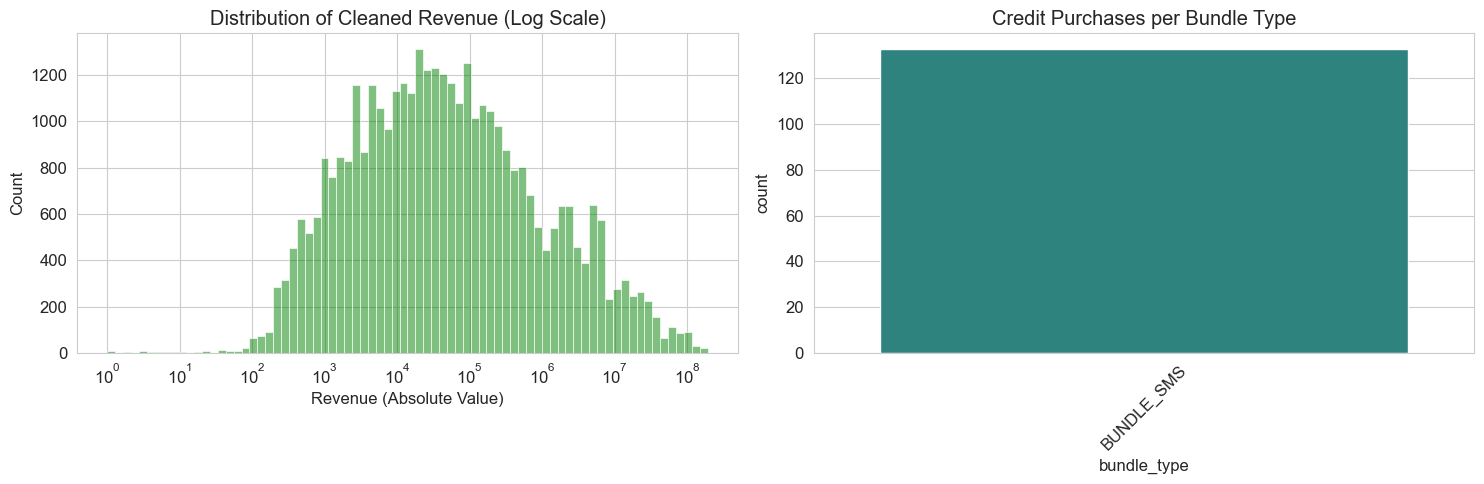

   - Number of records with zero value: 8


In [77]:

df['is_credit_purchase'] = (df['total_rev'] < 0).astype(int)


negative_sample_idx = df[df['total_rev'] < 0].head(5).index


df['total_rev_clean'] = df['total_rev'].abs()



print(" --- Checking Revenue Processing Results --- ")


print("\n Sample to verify transformation (values that were negative):")
if len(negative_sample_idx) > 0:
    display(df.loc[negative_sample_idx, ['bundle_name', 'total_rev', 'total_rev_clean', 'is_credit_purchase']])
else:
    print("No negative values found in this batch.")


print("\nStatistical Comparison (Before and After):")
comparison = pd.DataFrame({
    'Original (Raw)': df['total_rev'].describe(),
    'Cleaned (Absolute)': df['total_rev_clean'].describe()
})
display(comparison)


credit_count = df['is_credit_purchase'].sum()
print(f"\nCredit Statistics:")
print(f"   - Total credit purchases: {credit_count} ({ (credit_count/len(df))*100:.2f}%)")


plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
sns.histplot(df['total_rev_clean'], kde=True, color='green', log_scale=True)
plt.title('Distribution of Cleaned Revenue (Log Scale)')
plt.xlabel('Revenue (Absolute Value)')


plt.subplot(1, 2, 2)
sns.countplot(data=df[df['is_credit_purchase'] == 1], x='bundle_type', palette='viridis')
plt.title('Credit Purchases per Bundle Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


zeros_count = (df['total_rev_clean'] == 0).sum()
print(f"   - Number of records with zero value: {zeros_count}")

In [78]:
df.info()

<class 'pandas.DataFrame'>
Index: 37674 entries, 0 to 38045
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             37674 non-null  int64  
 1   year_number             37674 non-null  int64  
 2   bundle_id               37674 non-null  str    
 3   bundle_name             37674 non-null  str    
 4   bundle_type             37674 non-null  str    
 5   validity                37674 non-null  str    
 6   price                   37652 non-null  str    
 7   usage_type              37674 non-null  str    
 8   configured_volume       36617 non-null  str    
 9   service_class_category  37674 non-null  str    
 10  total_rev               37674 non-null  float64
 11  total_subscriptions     37674 non-null  int64  
 12  total_sessions          37674 non-null  int64  
 13  unique_users            37674 non-null  int64  
 14  validity_value          37674 non-null  float64
 15  v

In [79]:

cols_to_drop = [         
    'validity',          
    'price',             
    'configured_volume',  
    'volume_fill_source',
    'total_rev'
]


df_clean = df.drop(columns=cols_to_drop)

print(f"Remaining columns: {list(df_clean.columns)}")
print(f"Dataframe shape: {df_clean.shape}")

Remaining columns: ['week_number', 'year_number', 'bundle_id', 'bundle_name', 'bundle_type', 'usage_type', 'service_class_category', 'total_subscriptions', 'total_sessions', 'unique_users', 'validity_value', 'validity_unit', 'validity_unit_encoded', 'price_clean', 'volume_value', 'volume_unit', 'is_credit_purchase', 'total_rev_clean']
Dataframe shape: (37674, 18)


In [80]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 37674 entries, 0 to 38045
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   week_number             37674 non-null  int64  
 1   year_number             37674 non-null  int64  
 2   bundle_id               37674 non-null  str    
 3   bundle_name             37674 non-null  str    
 4   bundle_type             37674 non-null  str    
 5   usage_type              37674 non-null  str    
 6   service_class_category  37674 non-null  str    
 7   total_subscriptions     37674 non-null  int64  
 8   total_sessions          37674 non-null  int64  
 9   unique_users            37674 non-null  int64  
 10  validity_value          37674 non-null  float64
 11  validity_unit           37674 non-null  str    
 12  validity_unit_encoded   37674 non-null  float64
 13  price_clean             37674 non-null  float64
 14  volume_value            37674 non-null  float64
 15  v